# Part 0

In [6]:
!pip install seaborn

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize
import math
import os
import seaborn as sns

In [10]:
print(os.getcwd())

/home/nathaniel-jaffa/Coding/5b_labs/lab7


In [13]:
part0 = pd.read_csv("/home/nathaniel-jaffa/Coding/5b_labs/lab7/part0.csv")

In [15]:
part0.columns

Index(['Time (s)', 'Signal strength', 'Fᵧ (N)'], dtype='str')

In [16]:
part0.columns = ['t', 's', 'f']

In [17]:
part0.columns

Index(['t', 's', 'f'], dtype='str')

In [18]:
average = part0.loc[(part0['t'] >  3) & (part0['t'] < 5.5)]
average

,t,s,f
7200,3.000417,54.0,-1.780890
7201,3.000833,54.0,-1.789483
7202,3.001250,54.0,-1.815261
7203,3.001667,54.0,-1.823853
7204,3.002083,54.0,-1.841038
...,...,...,...
13194,5.497917,56.0,-2.408146
13195,5.498333,56.0,-2.408146
13196,5.498750,56.0,-2.408146
13197,5.499166,56.0,-2.408146


In [19]:
print(f'Mean = {average['f'].mean()}')
print(f'Error = {average['f'].std()}')

Mean = -2.3751879494713632
Error = 0.14230204110571246


# Part 1

In [21]:
part1 = pd.read_csv("/home/nathaniel-jaffa/Coding/5b_labs/lab7/part1.csv")

In [22]:
part1.columns

Index(['Time (s)', 'Fᵧ (N)', 'rᵧ (m)', 'vᵧ (m/s)', 'aᵧ (m/s²)'], dtype='str')

In [23]:
part1.columns = ['t1', 'f1', 'r1', 'v1', 'a1']

In [24]:
selection0 = part1.loc[(part1['t1'] > 4) & (part1['t1'] < 7.3)]

In [25]:
force1 = selection0["f1"]
dist1 = selection0["r1"]

p1, c1 = np.polyfit(force1, dist1, 1, cov=True)
m1 = p1[0]
b1 = p1[1]
e1 = np.sqrt(c1[0][0])

Estimated k value from -F/x: -12.455 with uncertainty: 15725.231


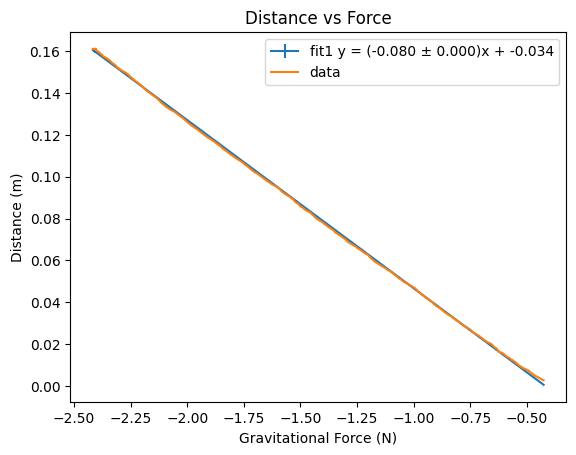

In [26]:
fit1 = [m1*x + b1 for x in force1]
plt.errorbar(force1, fit1, e1, label = f"fit1 y = ({m1:.3f} ± {e1:.3f})x + {b1:.3f}")
plt.errorbar(force1, dist1, label = "data")

plt.xlabel("Gravitational Force (N)")
plt.ylabel("Distance (m)")
plt.title("Distance vs Force")
plt.legend() 

print(f'Estimated k value from -F/x: {1/m1:.3f} with uncertainty: {1/e1:.3f}') 

In [33]:
#residuals 
def residual_plot(x, y, f, xlabel, title):
    y_act = y
    y_pred1 = f(x)
    y_res = y_act-y_pred1
    plt.figure(figsize=(8,5))
    sns.residplot(x=x,y=y_res,lowess=False, color="blue", line_kws={"color": "red"})

    plt.xlabel(xlabel)
    plt.ylabel("Residual")
    plt.title(f'Residual Plot: {title}')
    plt.show()

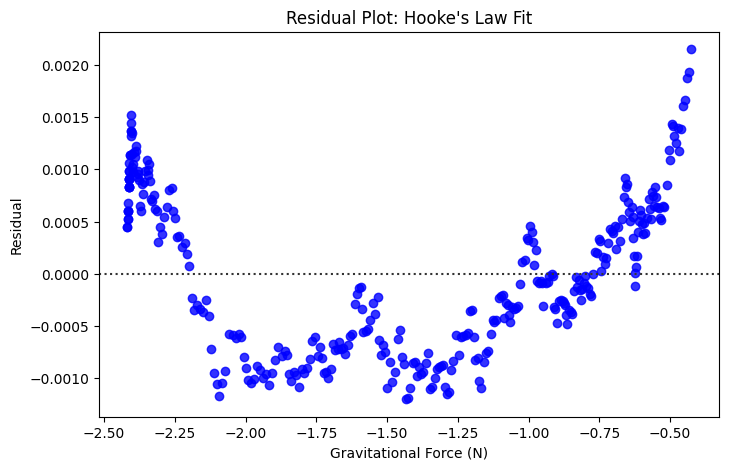

In [34]:
residual_plot(force1, dist1, lambda x: m1*x+b1,"Gravitational Force (N)", "Hooke's Law Fit")

# Part 2

In [36]:
part2 = pd.read_csv("/home/nathaniel-jaffa/Coding/5b_labs/lab7/part2.csv")

In [37]:
part2.columns 

Index(['Time (s)', 'Ax (m/s²)', 'Ay (m/s²)', 'Az (m/s²)', 'Fᵧ (N)'], dtype='str')

In [38]:
part2.columns = ['t2', 'ax2', 'ay2', 'az2', 'fy2']

In [39]:
part2.columns 

Index(['t2', 'ax2', 'ay2', 'az2', 'fy2'], dtype='str')

In [40]:
selection2 = part2.loc[(part2['t2'] > 1) & (part2['t2'] < 15)]

In [51]:
def sine(x, amplitude, b2, c2, d2):
    return (amplitude * (b2**2) * np.sin(b2*x +c2)) + d2

Text(0.5, 1.0, 'Acceleration vs Time: 0° Case')

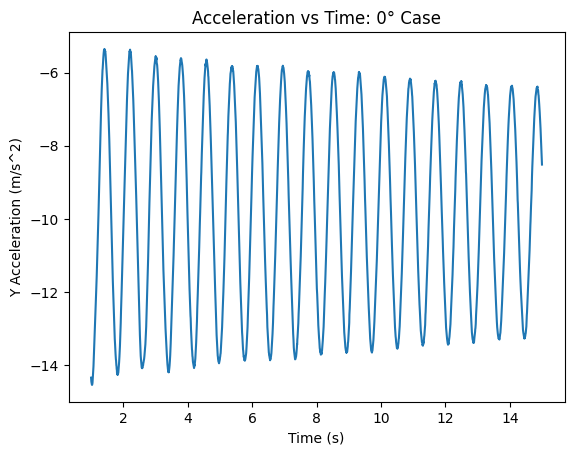

In [52]:
accel2 = selection2["ay2"]
time2 = selection2["t2"]

plt.plot(time2,accel2)
plt.xlabel("Time (s)")
plt.ylabel("Y Acceleration (m/s^2)")
plt.title("Acceleration vs Time: 0° Case")

In [53]:
guess2 = [0.07, 7.71, 4, -10]
p2, c2 = optimize.curve_fit(sine, time2, accel2, guess2)

7.961393235216157


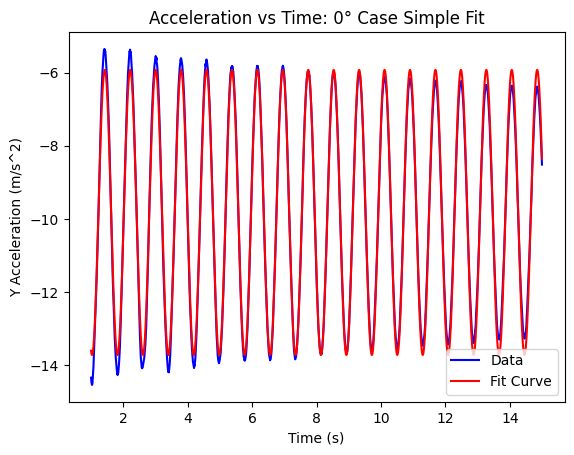

In [65]:
plt.plot(time2,accel2, color = 'blue', label = "Data")
print(p2[1])
plt.plot(time2, sine(time2, *p2), color ='red', label = "Fit Curve")


plt.xlabel("Time (s)")
plt.ylabel("Y Acceleration (m/s^2)")
plt.title("Acceleration vs Time: 0° Case Simple Fit")
plt.legend()

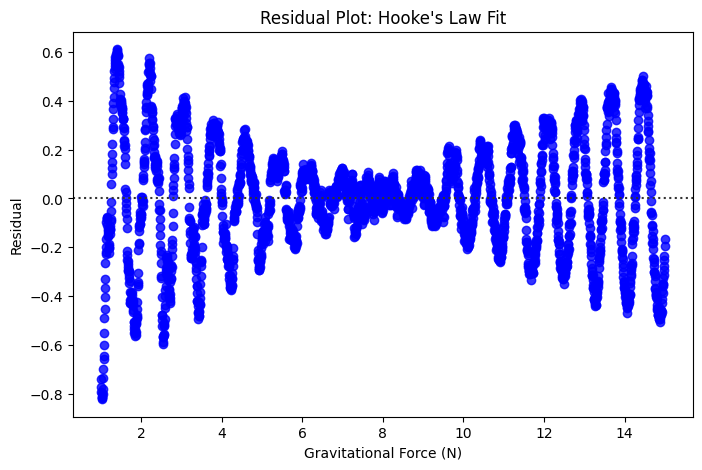

In [71]:
residual_plot(time2, accel2, lambda x: sine(time2, *p2),"Gravitational Force (N)", "Hooke's Law Fit")

In [72]:
def gracesstupidtry(t, amplitude, omega, phi, beta, c):
    return (amplitude*np.exp(-1*beta*t)*(((beta**2)-(omega**2))*(np.cos(omega*t+phi)) + 2*beta*omega*np.sin(omega*t+phi))) + c                           

In [73]:
guess2damp = [0.13, 8, 5.3, 0.3, -8]
p2, c2 = optimize.curve_fit(gracesstupidtry, time2, accel2, guess2damp)

[ 0.07189997  7.96088912  4.32167247  0.02002996 -9.81764271]


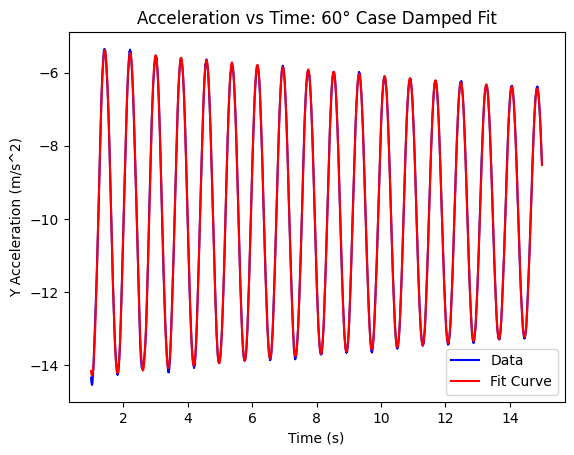

In [81]:
plt.plot(time2,accel2, color = 'blue', label = "Data")
print(p2)
plt.plot(time2, gracesstupidtry(time2, *p2), color ='red', label = "Fit Curve")

plt.xlabel("Time (s)")
plt.ylabel("Y Acceleration (m/s^2)")
plt.title("Acceleration vs Time: 60° Case Damped Fit")
plt.legend()

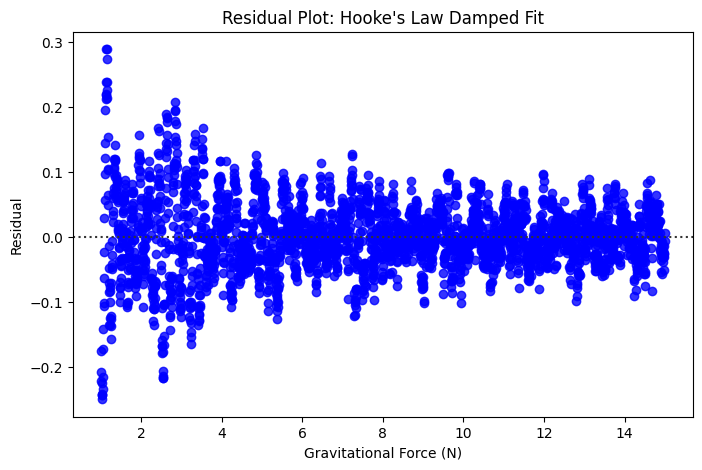

In [82]:
residual_plot(time2, accel2, lambda x: gracesstupidtry(time2, *p2),"Gravitational Force (N)", "Hooke's Law Damped Damped Fit")

# Part 3 (simple)

In [85]:
part3 = pd.read_csv("/home/nathaniel-jaffa/Coding/5b_labs/lab7/part3.csv")

In [86]:
part3.columns

Index(['Time (s)', 'Ax (m/s²)', 'Ay (m/s²)', 'Az (m/s²)', 'Fᵧ (N)'], dtype='str')

In [87]:
part3.columns = ['t3', 'ax3', 'ay3', 'az3', 'fy3']

In [88]:
part3.columns

Index(['t3', 'ax3', 'ay3', 'az3', 'fy3'], dtype='str')

In [89]:
selection3 = part3.loc[(part3['t3'] > .25 ) & (part3['t3'] < 8)]

In [90]:
def sine(x, amplitude, b, c, d):
    return (amplitude * (b**2) * np.sin(b*x +c)) + d

In [94]:
accel3 = selection3["ay3"]
time3 = selection3["t3"]
f = selection3["fy3"]

Text(0.5, 1.0, 'nates random graph- smooth force ')

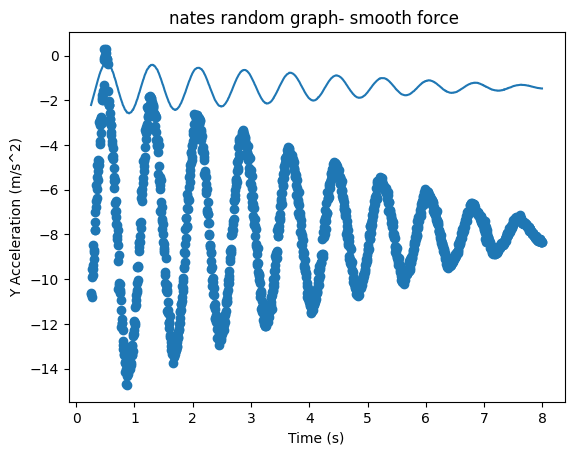

In [95]:
plt.scatter(time3,accel3)
plt.plot(time3,selection3["fy3"])

plt.xlabel("Time (s)")
plt.ylabel("Y Acceleration (m/s^2)")
plt.title("nates random graph- smooth force ")

In [97]:
guess3 = [0.1, 7.71, 4, -10]
p3, c3 = optimize.curve_fit(sine, time3, accel3, guess3)

7.939364138277493


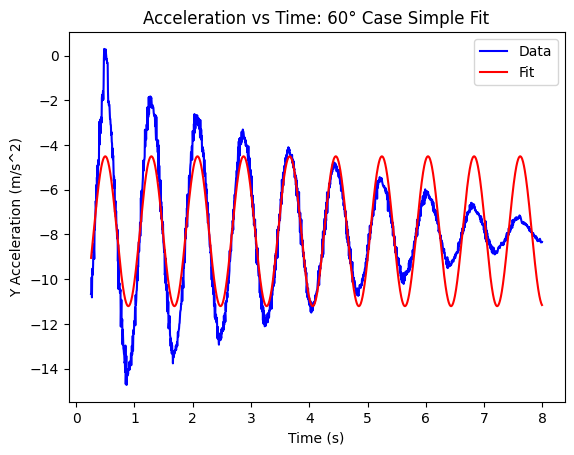

In [103]:
plt.plot(time3,accel3, color = 'blue', label = 'Data')
print(p3[1])
plt.plot(time3, sine(time3, *p3), color = 'red', label = 'Fit')

plt.xlabel("Time (s)")
plt.ylabel("Y Acceleration (m/s^2)")
plt.title("Acceleration vs Time: 60° Case Simple Fit")
plt.legend()

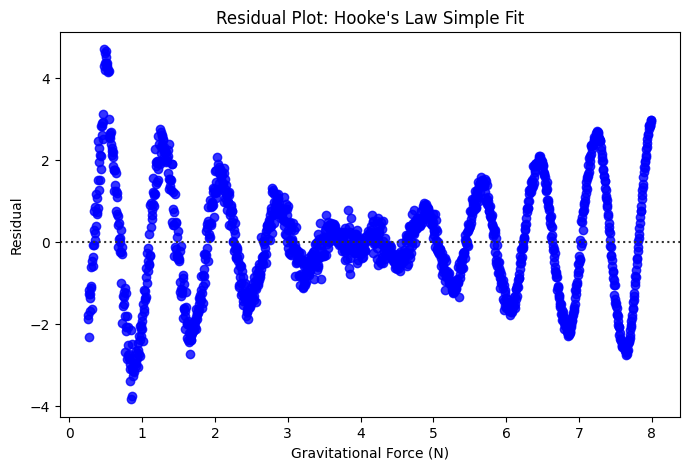

In [104]:
residual_plot(time3, accel3, lambda x: sine(time3, *p3),"Gravitational Force (N)", "Hooke's Law Simple Fit")

In [105]:
guess3damp = [0.13, 8, 5.3, 0.3, -8]
p3d, c3d = optimize.curve_fit(gracesstupidtry, time3, accel3, guess3damp)

[ 0.1287069   7.95544803  5.35782972  0.24714603 -7.90932436]


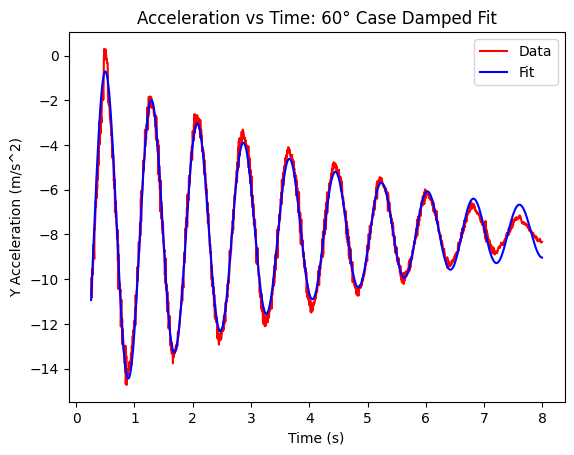

In [110]:
plt.plot(time3,accel3, color = 'red', label = 'Data')
print(p3d)
plt.plot(time3, gracesstupidtry(time3, *p3d), color = 'blue', label= 'Fit')

plt.xlabel("Time (s)")
plt.ylabel("Y Acceleration (m/s^2)")
plt.title("Acceleration vs Time: 60° Case Damped Fit")
plt.legend()

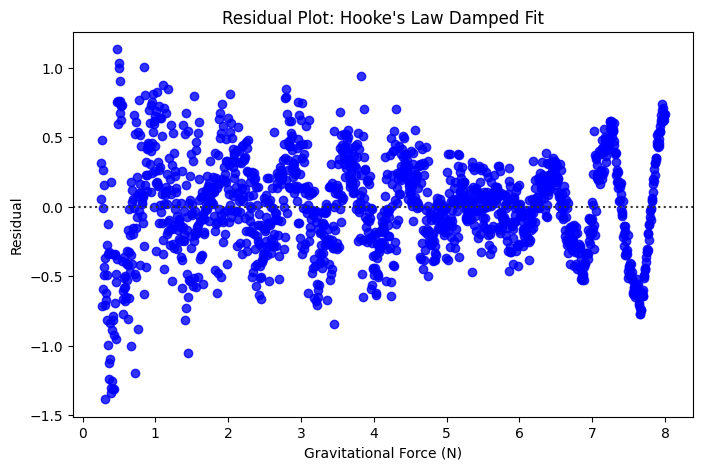

In [112]:
residual_plot(time3, accel3, lambda x:gracesstupidtry(time3, *p3d),"Gravitational Force (N)", "Hooke's Law Damped Fit")

In [113]:
t = []
a = []
f = list(f)
time = list(time3)
for i,x in enumerate(f):
    if (i != 0 and i != len(f)-1):
        if abs(f[i-1]) < abs(x) and abs(f[i+1]) < abs(x):
            skip = False
            for ti in t:
                if (abs(ti - time[i]) < 0.25):
                    skip = True
            if not skip:
                a.append(x)
                t.append(time[i])
t = t[:-3]   
a = a[:-2]

In [114]:
print(t)
print(len(t))

[0.5099999904632568, 0.875, 1.2649999856948853, 1.6649999618530271, 2.0899999141693115, 2.490000009536743, 2.869999885559082, 3.240000009536743, 3.660000085830689, 4.065000057220459, 4.460000038146973, 4.84499979019165, 5.210000038146973, 5.599999904632568, 5.985000133514404, 6.335000038146973, 6.760000228881836, 7.03000020980835]
18


In [115]:
a_diff = []
for x in range(len(a)-1):
    a_diff.append(abs(a[x] - a[x+1])) 
print(a_diff)



[2.483241021633148, 2.0768968164920807, 1.9155632555484776, 1.8437045216560368, 1.7300768494606018, 1.6239869594573975, 1.4607248306274414, 1.344730794429779, 1.2416204810142517, 1.121324896812439, 0.99504554271698, 0.8489760160446167, 0.7088829278945923, 0.5842927694320679, 0.4124490022659302, 0.30503690242767334, 0.12029564380645752, 0.17363989353179932]


In [116]:

p2, c2 = np.polyfit(t,a_diff, 1, cov=True)
m2 = p2[0]
b2 = p2[1]
e2 = np.sqrt(c2[0][0])

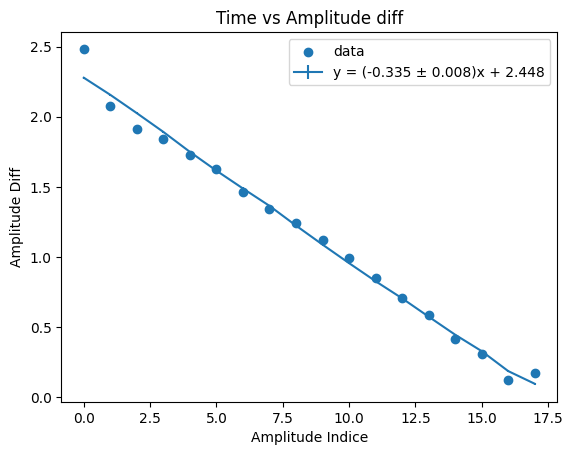

In [117]:
fit2 = [m2*x + b2 for x in t]
plt.errorbar(range(len(t)), fit2, e2, label = f"y = ({m2:.3f} ± {e2:.3f})x + {b2:.3f}")
plt.scatter(range(len(t)), a_diff, label = "data")

plt.xlabel("Amplitude Indice")
plt.ylabel("Amplitude Diff")
plt.title("Time vs Amplitude diff")
plt.legend()

In [ ]:
residual_plot()